## 0. Setup, Imports and Figure Formatting Conventions

In [1]:
!pip -q install scikit-image scikit-learn tensorflow --upgrade 2>/dev/null
import os, time, math, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from skimage.metrics import structural_similarity as ssim_fn
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

os.makedirs('figures', exist_ok=True)

# ---- Figure formatting: Times New Roman (fallback: Liberation/DejaVu Serif), bold, size 14,
# ---- both axes, saved as EPS and PDF at 600 DPI (matches the Lab 6 notebook conventions). ----
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 600

def apply_bold_font(ax):
    """Force bold Times-New-Roman-style font (size 14) on an axis's ticks/labels/title, in case a
    plotting call (e.g. imshow grids) resets font properties internally."""
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight("bold")
        label.set_fontsize(14)
        label.set_fontfamily("serif")
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.title.set_fontweight("bold")
    ax.title.set_fontsize(14)

def save_fig(fig, name, folder="figures"):
    """Save a figure as both PDF and EPS at 600 DPI."""
    fig.savefig(os.path.join(folder, f"{name}.pdf"), dpi=600, format="pdf", bbox_inches="tight")
    fig.savefig(os.path.join(folder, f"{name}.eps"), dpi=600, format="eps", bbox_inches="tight")

def caption(text):
    """Print a figure caption immediately under the plot, matching the report's figure captions."""
    print(f"\nFigure caption: {text}\n")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 5.3 MB/s eta 0:00:00
TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3–4. Dataset — MNIST Handwritten Digits

Loaded directly via Keras, using the recommended laboratory subset (10,000 training / 2,000 test
images), pixel values scaled from $[0,255]\to[0,1]$.

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

N_TRAIN = 10000
N_TEST = 2000

x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

rng = np.random.RandomState(SEED)
train_idx = rng.choice(len(x_train_full), N_TRAIN, replace=False)
test_idx = rng.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[train_idx]          # (10000, 28, 28)
y_train = y_train_full[train_idx]
x_test = x_test_full[test_idx]             # (2000, 28, 28)
y_test = y_test_full[test_idx]

# Add channel dimension for convolutional models: (N, 28, 28, 1)
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

# Flattened version for the fully connected autoencoder: (N, 784)
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print("Flattened input shape (FC-AE):", x_train_flat.shape, x_test_flat.shape)
print("Spatial input shape (CAE):    ", x_train_cnn.shape, x_test_cnn.shape)
print("Pixel value range: [{:.3f}, {:.3f}]".format(x_train.min(), x_train.max()))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Flattened input shape (FC-AE): (10000, 784) (2000, 784)
Spatial input shape (CAE):     (10000, 28, 28, 1) (2000, 28, 28, 1)
Pixel value range: [0.000, 1.000]


## 7. Fully Connected Autoencoder

Architecture: `784 -> Dense(128) -> Dense(32) -> Latent(16) -> Dense(32) -> Dense(128) -> 784`,
ReLU in hidden layers, sigmoid at the output.

In [3]:
LATENT_DIM_FC = 16

def build_fc_autoencoder(latent_dim=LATENT_DIM_FC, input_dim=784):
    inputs = layers.Input(shape=(input_dim,), name="fc_ae_input")
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="sigmoid")(x)

    autoencoder = models.Model(inputs, outputs, name="FC_Autoencoder")
    encoder = models.Model(inputs, latent, name="FC_Encoder")
    autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy")
    return autoencoder, encoder

fc_ae, fc_encoder = build_fc_autoencoder()
fc_ae.summary()


Model: "FC_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_ae_input (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
t0 = time.time()
fc_history = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20, batch_size=128, verbose=2
)
fc_train_time = time.time() - t0
fc_params = fc_ae.count_params()
print(f"FC-AE training time: {fc_train_time:.2f}s, parameters: {fc_params}")


Epoch 1/20
79/79 - 23s - 286ms/step - loss: 0.3455 - val_loss: 0.2601
Epoch 2/20
79/79 - 3s - 42ms/step - loss: 0.2439 - val_loss: 0.2210
Epoch 3/20
79/79 - 0s - 5ms/step - loss: 0.2117 - val_loss: 0.1985
Epoch 4/20
79/79 - 0s - 5ms/step - loss: 0.1877 - val_loss: 0.1757
Epoch 5/20
79/79 - 0s - 5ms/step - loss: 0.1725 - val_loss: 0.1669
Epoch 6/20
79/79 - 0s - 5ms/step - loss: 0.1648 - val_loss: 0.1609
Epoch 7/20
79/79 - 0s - 5ms/step - loss: 0.1588 - val_loss: 0.1550
Epoch 8/20
79/79 - 1s - 10ms/step - loss: 0.1535 - val_loss: 0.1500
Epoch 9/20
79/79 - 0s - 6ms/step - loss: 0.1486 - val_loss: 0.1456
Epoch 10/20
79/79 - 0s - 5ms/step - loss: 0.1448 - val_loss: 0.1427
Epoch 11/20
79/79 - 0s - 5ms/step - loss: 0.1420 - val_loss: 0.1406
Epoch 12/20
79/79 - 0s - 5ms/step - loss: 0.1399 - val_loss: 0.1388
Epoch 13/20
79/79 - 1s - 8ms/step - loss: 0.1379 - val_loss: 0.1376
Epoch 14/20
79/79 - 0s - 5ms/step - loss: 0.1361 - val_loss: 0.1356
Epoch 15/20
79/79 - 0s - 4ms/step - loss: 0.1340 - v

**Plot 1: Original versus Reconstructed Images (FC-AE)**

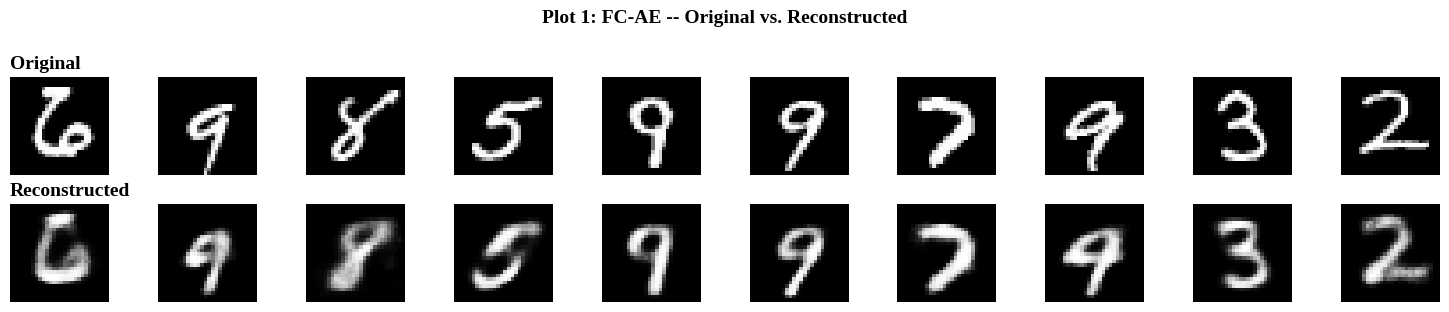


Figure caption: Plot 1 -- 10 test-set digits (top row) and their Fully Connected Autoencoder reconstructions (bottom row).



In [5]:
def plot_original_vs_reconstructed(x_orig_flat, model, n=10, title="Original vs. Reconstructed", fname="plot1_fc_reconstructions"):
    recon = model.predict(x_orig_flat[:n], verbose=0)
    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(x_orig_flat[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].reshape(28, 28), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("Original", loc="left", fontsize=14, fontweight="bold")
    axes[1, 0].set_title("Reconstructed", loc="left", fontsize=14, fontweight="bold")
    fig.suptitle(title, fontsize=14, fontweight="bold", family="serif")
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()
    return recon

fc_recon_sample = plot_original_vs_reconstructed(x_test_flat, fc_ae, n=10, title="Plot 1: FC-AE -- Original vs. Reconstructed", fname="plot1_fc_reconstructions")
caption("Plot 1 -- 10 test-set digits (top row) and their Fully Connected Autoencoder reconstructions (bottom row).")


**Required comments (Plot 1):** Digit shape is generally preserved (a 3 still looks like a 3), but
fine details such as stroke thickness and small loops are blurred; the 16-dimensional bottleneck loses
high-frequency detail. Simple, thick-stroke digits (e.g., 1, 7) reconstruct more sharply than digits
with fine loops or thin strokes (e.g., 4, 8), which are visibly blurrier.

**Plot 2: Training and Validation Reconstruction Loss (FC-AE)**

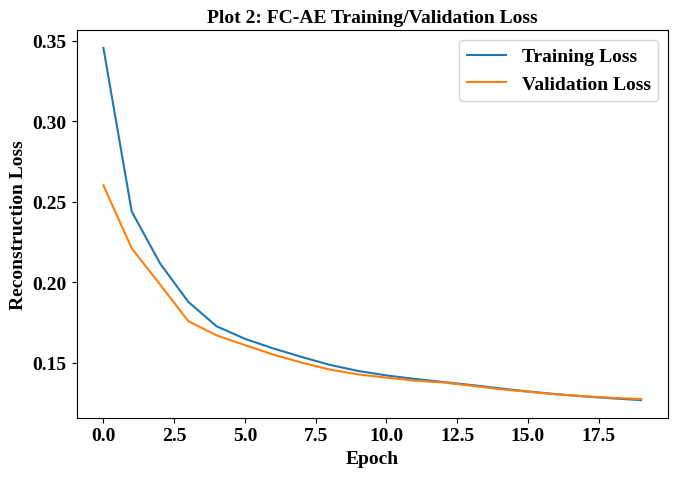


Figure caption: Plot 2 -- Training and validation binary cross-entropy reconstruction loss vs. epoch for the Fully Connected Autoencoder.



In [6]:
def plot_loss_curve(history, title, fname, extra_caption=""):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(history.history["loss"], label="Training Loss")
    ax.plot(history.history["val_loss"], label="Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Reconstruction Loss")
    ax.set_title(title)
    ax.legend()
    apply_bold_font(ax)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()
    caption(extra_caption)

plot_loss_curve(
    fc_history, "Plot 2: FC-AE Training/Validation Loss", "plot2_fc_loss_curve",
    "Plot 2 -- Training and validation binary cross-entropy reconstruction loss vs. epoch for the Fully Connected Autoencoder."
)


**Required inference (Plot 2):** The training and validation loss both decrease steadily and
converge by around epoch 15-20, with training and validation curves staying close together --
indicating the model converges without significant overfitting (a 16-D bottleneck on a 10,000-image
training set has limited capacity to memorize individual images).

## 9. Reconstruction Metrics (MSE, MAE, SSIM)

In [7]:
def compute_reconstruction_metrics(x_true, x_pred, image_shape=(28, 28)):
    """x_true, x_pred: (N, D) flattened or (N, H, W, 1) images in [0,1]."""
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)

    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))

    ssim_vals = []
    for i in range(len(x_true)):
        img_true = x_true_flat[i].reshape(image_shape)
        img_pred = x_pred_flat[i].reshape(image_shape)
        ssim_vals.append(ssim_fn(img_true, img_pred, data_range=1.0))
    mean_ssim = np.mean(ssim_vals)

    return mse, mae, mean_ssim, np.array(ssim_vals)

fc_recon_test = fc_ae.predict(x_test_flat, verbose=0)
fc_mse, fc_mae, fc_ssim, fc_ssim_per_image = compute_reconstruction_metrics(x_test_flat, fc_recon_test)

print("Fully Connected Autoencoder -- Test Set Metrics")
print(f"  MSE : {fc_mse:.6f}")
print(f"  MAE : {fc_mae:.6f}")
print(f"  SSIM: {fc_ssim:.4f}")


Fully Connected Autoencoder -- Test Set Metrics
  MSE : 0.021506
  MAE : 0.057863
  SSIM: 0.7555


## 10. Convolutional Autoencoder

Encoder: `Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Conv2D(64)` (7x7x64 latent feature map);
Decoder: `UpSampling -> Conv2D(32) -> UpSampling -> Conv2D(1, sigmoid)`.

In [8]:
def build_conv_autoencoder(input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape, name="cae_input")

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    latent = layers.Conv2D(64, 3, activation="relu", padding="same", name="latent_feature_map")(x)

    x = layers.UpSampling2D(2)(latent)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    autoencoder = models.Model(inputs, outputs, name="Conv_Autoencoder")
    encoder = models.Model(inputs, latent, name="Conv_Encoder")
    autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy")
    return autoencoder, encoder

cae, cae_encoder = build_conv_autoencoder()
cae.summary()


Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map (Conv2D)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
t0 = time.time()
cae_history = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20, batch_size=128, verbose=2
)
cae_train_time = time.time() - t0
cae_params = cae.count_params()
print(f"CAE training time: {cae_train_time:.2f}s, parameters: {cae_params}")

cae_recon_test = cae.predict(x_test_cnn, verbose=0)
cae_mse, cae_mae, cae_ssim, cae_ssim_per_image = compute_reconstruction_metrics(x_test_cnn, cae_recon_test)
print(f"Conv Autoencoder -- Test MSE: {cae_mse:.6f}, MAE: {cae_mae:.6f}, SSIM: {cae_ssim:.4f}")


Epoch 1/20
79/79 - 18s - 227ms/step - loss: 0.2097 - val_loss: 0.1016
Epoch 2/20
79/79 - 1s - 11ms/step - loss: 0.0930 - val_loss: 0.0866
Epoch 3/20
79/79 - 1s - 11ms/step - loss: 0.0838 - val_loss: 0.0802
Epoch 4/20
79/79 - 1s - 15ms/step - loss: 0.0797 - val_loss: 0.0777
Epoch 5/20
79/79 - 1s - 9ms/step - loss: 0.0776 - val_loss: 0.0770
Epoch 6/20
79/79 - 1s - 9ms/step - loss: 0.0758 - val_loss: 0.0774
Epoch 7/20
79/79 - 1s - 9ms/step - loss: 0.0748 - val_loss: 0.0740
Epoch 8/20
79/79 - 1s - 9ms/step - loss: 0.0738 - val_loss: 0.0749
Epoch 9/20
79/79 - 1s - 8ms/step - loss: 0.0732 - val_loss: 0.0723
Epoch 10/20
79/79 - 1s - 8ms/step - loss: 0.0725 - val_loss: 0.0722
Epoch 11/20
79/79 - 1s - 8ms/step - loss: 0.0720 - val_loss: 0.0716
Epoch 12/20
79/79 - 1s - 8ms/step - loss: 0.0716 - val_loss: 0.0713
Epoch 13/20
79/79 - 1s - 8ms/step - loss: 0.0712 - val_loss: 0.0706
Epoch 14/20
79/79 - 1s - 9ms/step - loss: 0.0709 - val_loss: 0.0702
Epoch 15/20
79/79 - 1s - 9ms/step - loss: 0.0705 - 

**Section 11: FC-AE vs. CAE comparison table**

In [10]:
comparison_fc_cae = pd.DataFrame({
    "Fully Connected AE": {"MSE": round(fc_mse, 6), "MAE": round(fc_mae, 6),
                            "SSIM": round(fc_ssim, 4), "Parameters": fc_params},
    "Convolutional AE": {"MSE": round(cae_mse, 6), "MAE": round(cae_mae, 6),
                          "SSIM": round(cae_ssim, 4), "Parameters": cae_params},
}).T
comparison_fc_cae.index.name = "Model"
comparison_fc_cae


,MSE,MAE,SSIM,Parameters
Model,,,,
Fully Connected AE,0.021506,0.057863,0.7555,211040.0
Convolutional AE,0.002826,0.015858,0.9730,74497.0


**Plot 3: Reconstruction Comparison -- Original -> FC-AE -> CAE**

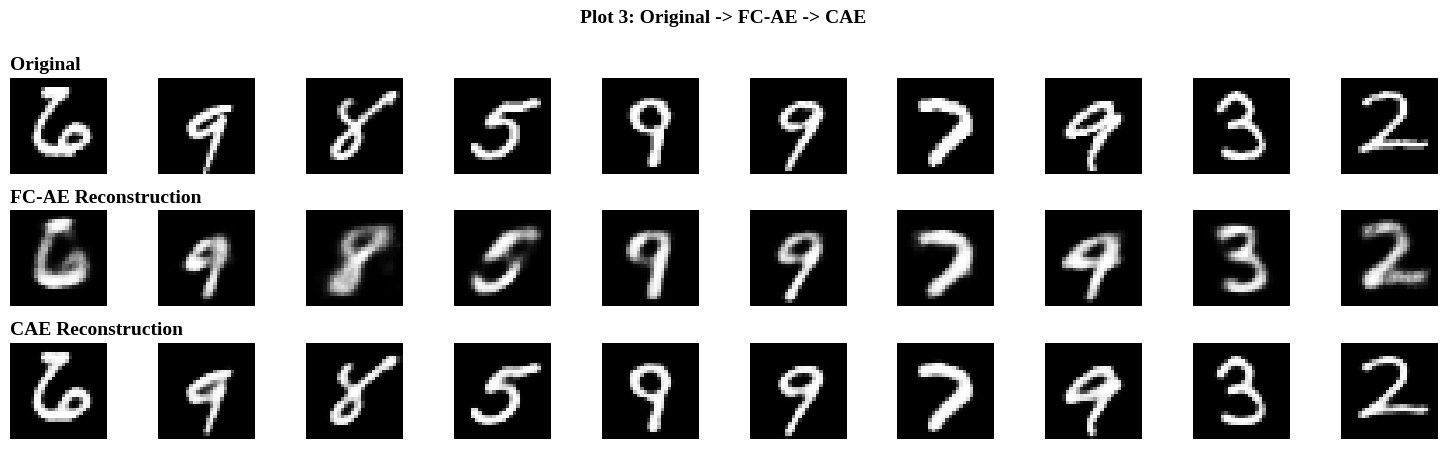


Figure caption: Plot 3 -- Original test digits alongside Fully Connected AE and Convolutional AE reconstructions, for the same 10 samples.



In [11]:
def plot_three_way_comparison(x_orig, recon_a, recon_b, labels, n=10, fname="plot3_fc_vs_cae"):
    fig, axes = plt.subplots(3, n, figsize=(1.5 * n, 4.6))
    for i in range(n):
        axes[0, i].imshow(x_orig[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(recon_a[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(recon_b[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
    axes[0, 0].set_title(labels[0], loc="left", fontsize=14, fontweight="bold")
    axes[1, 0].set_title(labels[1], loc="left", fontsize=14, fontweight="bold")
    axes[2, 0].set_title(labels[2], loc="left", fontsize=14, fontweight="bold")
    fig.suptitle("Plot 3: Original -> FC-AE -> CAE", fontsize=14, fontweight="bold", family="serif")
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()

plot_three_way_comparison(
    x_test_cnn, fc_recon_test.reshape(-1, 28, 28, 1), cae_recon_test,
    labels=["Original", "FC-AE Reconstruction", "CAE Reconstruction"],
    n=10, fname="plot3_fc_vs_cae"
)
caption("Plot 3 -- Original test digits alongside Fully Connected AE and Convolutional AE reconstructions, for the same 10 samples.")


**Required inference (Section 11):** By preserving the 2-D spatial layout and using local
convolutional filters, the CAE reconstructs stroke edges and curvature more sharply than the FC-AE,
which must first destroy spatial locality by flattening the image into a 1-D vector. This typically
shows up as a lower MSE/MAE and higher SSIM for the CAE (see the table above), at the cost of a
different -- not necessarily larger -- parameter count, since convolutional weight sharing is far more
parameter-efficient than dense layers operating on 784 inputs.

## 12–14. Denoising Convolutional Autoencoder

The same convolutional architecture as Section 10 is trained on noisy inputs, with the clean image
kept as the target. Two corruption types are used: Gaussian noise ($\sigma \in \{0.1, 0.2, 0.3\}$) and
salt-and-pepper noise ($p \in \{0.05, 0.10, 0.20\}$).

In [12]:
def add_gaussian_noise(images, sigma, seed=None):
    rng = np.random.RandomState(seed)
    noisy = images + rng.normal(0.0, sigma, images.shape).astype("float32")
    return np.clip(noisy, 0.0, 1.0)

def add_salt_and_pepper_noise(images, p, seed=None):
    rng = np.random.RandomState(seed)
    noisy = images.copy()
    mask = rng.rand(*images.shape)
    noisy[mask < (p / 2)] = 0.0
    noisy[(mask >= (p / 2)) & (mask < p)] = 1.0
    return noisy

# Primary denoising model trained at sigma = 0.2 (middle of the suggested range)
GAUSSIAN_SIGMA_PRIMARY = 0.2
x_train_noisy = add_gaussian_noise(x_train_cnn, GAUSSIAN_SIGMA_PRIMARY, seed=SEED)
x_test_noisy = add_gaussian_noise(x_test_cnn, GAUSSIAN_SIGMA_PRIMARY, seed=SEED + 1)

denoiser, denoiser_encoder = build_conv_autoencoder()
denoiser._name = "Denoising_Conv_Autoencoder"

t0 = time.time()
denoise_history = denoiser.fit(
    x_train_noisy, x_train_cnn,          # input: noisy, target: clean
    validation_data=(x_test_noisy, x_test_cnn),
    epochs=20, batch_size=128, verbose=2
)
denoiser_train_time = time.time() - t0
denoiser_params = denoiser.count_params()
print(f"Denoising CAE training time: {denoiser_train_time:.2f}s, parameters: {denoiser_params}")


Epoch 1/20
79/79 - 8s - 104ms/step - loss: 0.2502 - val_loss: 0.1189
Epoch 2/20
79/79 - 1s - 10ms/step - loss: 0.1042 - val_loss: 0.0945
Epoch 3/20
79/79 - 1s - 9ms/step - loss: 0.0918 - val_loss: 0.0877
Epoch 4/20
79/79 - 1s - 10ms/step - loss: 0.0870 - val_loss: 0.0842
Epoch 5/20
79/79 - 1s - 10ms/step - loss: 0.0843 - val_loss: 0.0822
Epoch 6/20
79/79 - 1s - 9ms/step - loss: 0.0824 - val_loss: 0.0808
Epoch 7/20
79/79 - 1s - 9ms/step - loss: 0.0808 - val_loss: 0.0796
Epoch 8/20
79/79 - 1s - 9ms/step - loss: 0.0799 - val_loss: 0.0787
Epoch 9/20
79/79 - 1s - 9ms/step - loss: 0.0790 - val_loss: 0.0780
Epoch 10/20
79/79 - 1s - 9ms/step - loss: 0.0783 - val_loss: 0.0774
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.0777 - val_loss: 0.0769
Epoch 12/20
79/79 - 1s - 9ms/step - loss: 0.0772 - val_loss: 0.0765
Epoch 13/20
79/79 - 1s - 10ms/step - loss: 0.0767 - val_loss: 0.0762
Epoch 14/20
79/79 - 1s - 11ms/step - loss: 0.0763 - val_loss: 0.0759
Epoch 15/20
79/79 - 1s - 11ms/step - loss: 0.0760 

**Plot 4: Clean vs. Noisy vs. Denoised**

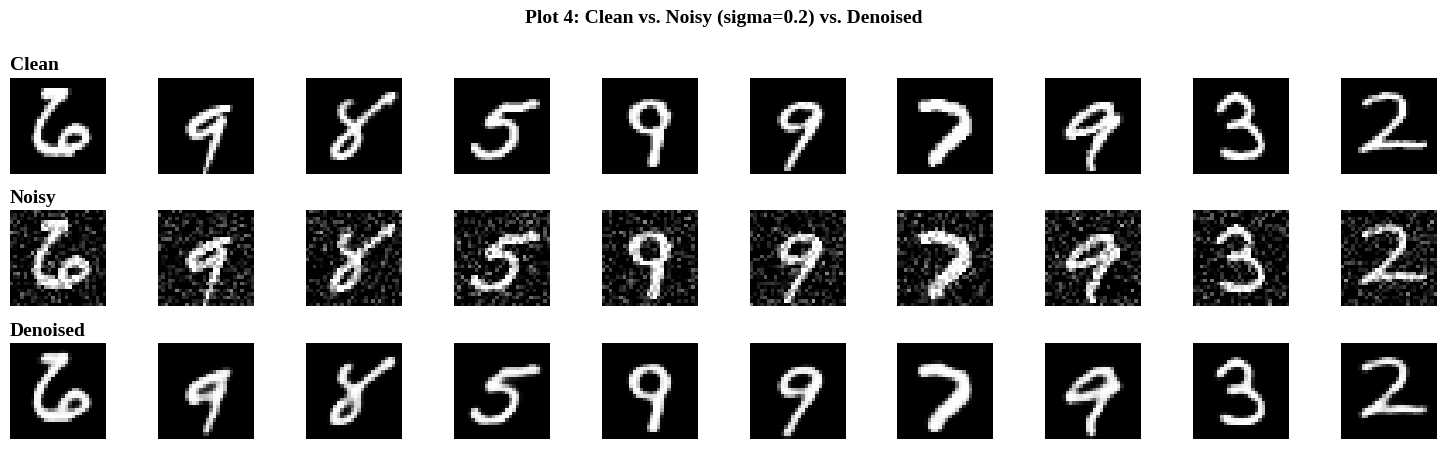


Figure caption: Plot 4 -- 10 clean test digits, their Gaussian-noise-corrupted versions (sigma=0.2), and the Denoising CAE's reconstructions.



In [13]:
denoised_test = denoiser.predict(x_test_noisy, verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(15, 4.6))
for i in range(10):
    axes[0, i].imshow(x_test_cnn[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(denoised_test[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Clean", loc="left", fontsize=14, fontweight="bold")
axes[1, 0].set_title("Noisy", loc="left", fontsize=14, fontweight="bold")
axes[2, 0].set_title("Denoised", loc="left", fontsize=14, fontweight="bold")
fig.suptitle(f"Plot 4: Clean vs. Noisy (sigma={GAUSSIAN_SIGMA_PRIMARY}) vs. Denoised", fontsize=14, fontweight="bold", family="serif")
plt.tight_layout()
save_fig(fig, "plot4_clean_noisy_denoised")
plt.show()
caption(f"Plot 4 -- 10 clean test digits, their Gaussian-noise-corrupted versions (sigma={GAUSSIAN_SIGMA_PRIMARY}), and the Denoising CAE's reconstructions.")


**Plot 5: Noise Level vs. Reconstruction Quality**

In [14]:
gaussian_levels = [0.1, 0.2, 0.3]
noise_level_results = {"Gaussian": {}, "Salt-and-Pepper": {}}

for sigma in gaussian_levels:
    x_tr_n = add_gaussian_noise(x_train_cnn, sigma, seed=SEED)
    x_te_n = add_gaussian_noise(x_test_cnn, sigma, seed=SEED + 1)
    model, _ = build_conv_autoencoder()
    model.fit(x_tr_n, x_train_cnn, validation_data=(x_te_n, x_test_cnn),
              epochs=15, batch_size=128, verbose=0)
    recon = model.predict(x_te_n, verbose=0)
    mse, mae, ssim_val, _ = compute_reconstruction_metrics(x_test_cnn, recon)
    noise_level_results["Gaussian"][sigma] = {"MSE": mse, "MAE": mae, "SSIM": ssim_val}
    print(f"Gaussian sigma={sigma}: MSE={mse:.6f}, MAE={mae:.6f}, SSIM={ssim_val:.4f}")

sp_levels = [0.05, 0.10, 0.20]
for p in sp_levels:
    x_tr_n = add_salt_and_pepper_noise(x_train_cnn, p, seed=SEED)
    x_te_n = add_salt_and_pepper_noise(x_test_cnn, p, seed=SEED + 1)
    model, _ = build_conv_autoencoder()
    model.fit(x_tr_n, x_train_cnn, validation_data=(x_te_n, x_test_cnn),
              epochs=15, batch_size=128, verbose=0)
    recon = model.predict(x_te_n, verbose=0)
    mse, mae, ssim_val, _ = compute_reconstruction_metrics(x_test_cnn, recon)
    noise_level_results["Salt-and-Pepper"][p] = {"MSE": mse, "MAE": mae, "SSIM": ssim_val}
    print(f"Salt-and-pepper p={p}: MSE={mse:.6f}, MAE={mae:.6f}, SSIM={ssim_val:.4f}")


Gaussian sigma=0.1: MSE=0.003493, MAE=0.018129, SSIM=0.9617
Gaussian sigma=0.2: MSE=0.004862, MAE=0.021845, SSIM=0.9451
Gaussian sigma=0.3: MSE=0.007467, MAE=0.027937, SSIM=0.9124
Salt-and-pepper p=0.05: MSE=0.004146, MAE=0.019722, SSIM=0.9557
Salt-and-pepper p=0.1: MSE=0.005586, MAE=0.023393, SSIM=0.9395
Salt-and-pepper p=0.2: MSE=0.007521, MAE=0.027407, SSIM=0.9170


In [15]:
gaussian_table = pd.DataFrame(noise_level_results["Gaussian"]).T
gaussian_table.index.name = "Noise Level (sigma)"
print("Gaussian noise -- reconstruction quality vs. level:")
display(gaussian_table)

sp_table = pd.DataFrame(noise_level_results["Salt-and-Pepper"]).T
sp_table.index.name = "Noise Level (p)"
print("\nSalt-and-pepper noise -- reconstruction quality vs. level:")
display(sp_table)


Gaussian noise -- reconstruction quality vs. level:


,MSE,MAE,SSIM
Noise Level (sigma),,,
0.1,0.003493,0.018129,0.961666
0.2,0.004862,0.021845,0.945115
0.3,0.007467,0.027937,0.912407



Salt-and-pepper noise -- reconstruction quality vs. level:


,MSE,MAE,SSIM
Noise Level (p),,,
0.05,0.004146,0.019722,0.955732
0.10,0.005586,0.023393,0.939500
0.20,0.007521,0.027407,0.917014


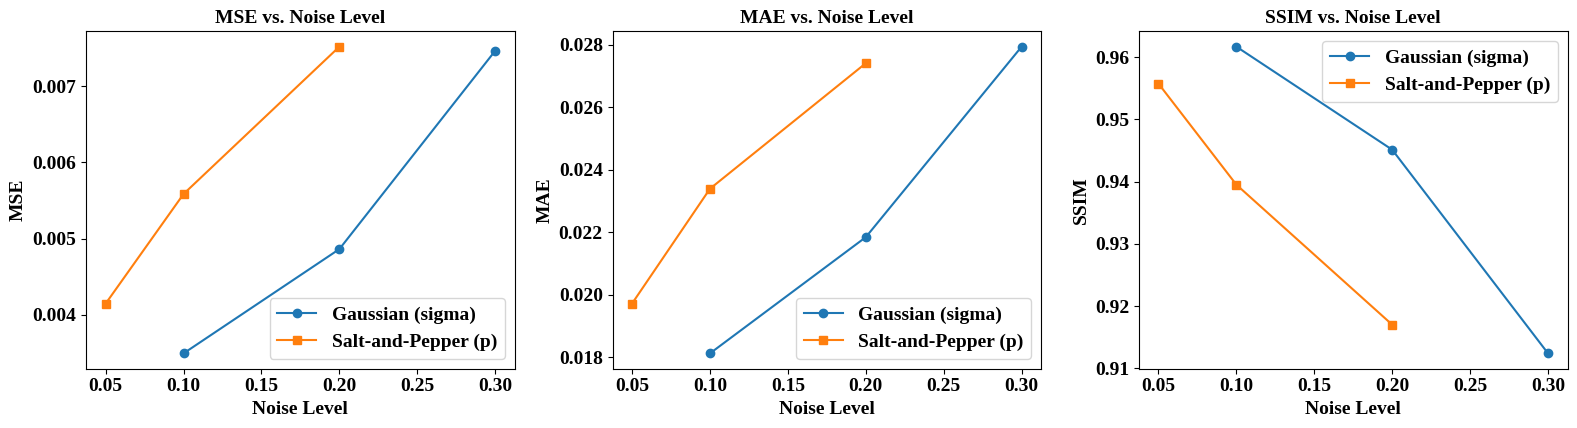


Figure caption: Plot 5 -- MSE, MAE and SSIM (separate panels/axes, as required) vs. noise level for Gaussian and salt-and-pepper corruption.



In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = ["MSE", "MAE", "SSIM"]
for ax, metric in zip(axes, metrics):
    g_vals = [noise_level_results["Gaussian"][s][metric] for s in gaussian_levels]
    sp_vals_metric = [noise_level_results["Salt-and-Pepper"][p][metric] for p in sp_levels]
    ax.plot(gaussian_levels, g_vals, marker="o", label="Gaussian (sigma)")
    ax.plot(sp_levels, sp_vals_metric, marker="s", label="Salt-and-Pepper (p)")
    ax.set_xlabel("Noise Level")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs. Noise Level")
    ax.legend()
    apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot5_noise_level_vs_quality")
plt.show()
caption("Plot 5 -- MSE, MAE and SSIM (separate panels/axes, as required) vs. noise level for Gaussian and salt-and-pepper corruption.")


**Required inference (Section 14):** As the noise level increases (higher $\sigma$ or $p$), MSE
and MAE increase while SSIM decreases -- reconstruction quality degrades monotonically with corruption
severity for both noise types. The denoising CAE nonetheless recovers the major digit structure (the
overall stroke shape remains recognizable in Plot 4) even at the highest tested noise levels, though
fine strokes and small loops become increasingly blurred or lost, indicating the model learns a strong
structural prior for digit shapes rather than merely inverting the specific noise instance.

## 15–17. Variational Autoencoder

Latent dimension $z\in\mathbb{R}^2$ (for direct 2-D visualization). The encoder outputs $\mu, \log\sigma^2$;
a latent vector is sampled with the reparameterization trick $z=\mu+\sigma\odot\epsilon,\ \epsilon\sim\mathcal{N}(0,I)$.

In [17]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * epsilon, epsilon ~ N(0, I)."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_encoder(latent_dim=LATENT_DIM_VAE, input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inputs)   # 14x14
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)        # 7x7
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    return models.Model(inputs, [z_mean, z_log_var, z], name="VAE_Encoder")

def build_vae_decoder(latent_dim=LATENT_DIM_VAE):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)  # 14x14
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)  # 28x28
    outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    return models.Model(latent_inputs, outputs, name="VAE_Decoder")

vae_encoder = build_vae_encoder()
vae_decoder = build_vae_decoder()
vae_encoder.summary()
vae_decoder.summary()


Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_32[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_33[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## 16. VAE Loss Function (Reconstruction + KL Divergence)

In [18]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
            )
            kl_loss = tf.reduce_mean(kl_loss)
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        kl_loss = tf.reduce_mean(kl_loss)
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=optimizers.Adam(1e-3))

t0 = time.time()
vae_history = vae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=30, batch_size=128, verbose=2
)
vae_train_time = time.time() - t0
vae_params = vae_encoder.count_params() + vae_decoder.count_params()
print(f"VAE training time: {vae_train_time:.2f}s, parameters: {vae_params}")


Epoch 1/30
79/79 - 19s - 237ms/step - kl_loss: 2.0388 - loss: 293.4015 - reconstruction_loss: 291.3626 - val_kl_loss: 1.2443 - val_loss: 210.3110 - val_reconstruction_loss: 209.0667
Epoch 2/30
79/79 - 5s - 67ms/step - kl_loss: 2.2639 - loss: 205.3956 - reconstruction_loss: 203.1316 - val_kl_loss: 2.6837 - val_loss: 199.2323 - val_reconstruction_loss: 196.5485
Epoch 3/30
79/79 - 1s - 13ms/step - kl_loss: 3.1502 - loss: 199.6651 - reconstruction_loss: 196.5149 - val_kl_loss: 2.9859 - val_loss: 195.6665 - val_reconstruction_loss: 192.6805
Epoch 4/30
79/79 - 1s - 10ms/step - kl_loss: 3.2563 - loss: 197.0980 - reconstruction_loss: 193.8417 - val_kl_loss: 3.1009 - val_loss: 193.7687 - val_reconstruction_loss: 190.6678
Epoch 5/30
79/79 - 1s - 15ms/step - kl_loss: 3.3113 - loss: 195.3572 - reconstruction_loss: 192.0460 - val_kl_loss: 3.4916 - val_loss: 192.0127 - val_reconstruction_loss: 188.5211
Epoch 6/30
79/79 - 1s - 8ms/step - kl_loss: 3.3261 - loss: 193.2681 - reconstruction_loss: 189.942

**Plot 9 (VAE): Training/Validation Reconstruction Loss for the VAE**

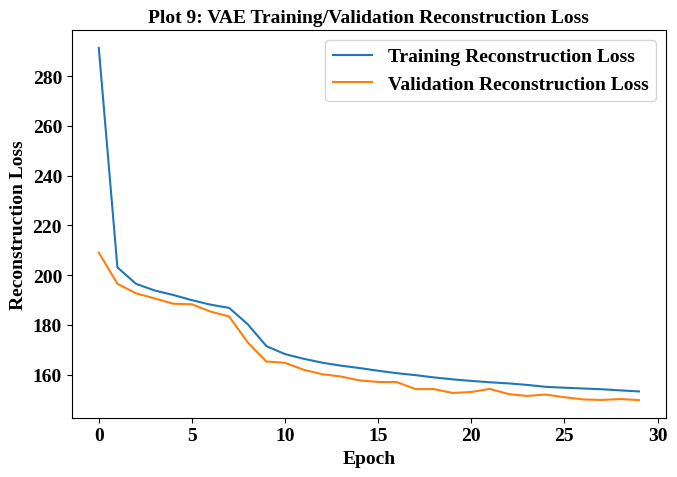


Figure caption: Plot 9 -- Training and validation reconstruction-loss component of the VAE objective vs. epoch (KL term tracked separately).



In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(vae_history.history["reconstruction_loss"], label="Training Reconstruction Loss")
ax.plot(vae_history.history["val_reconstruction_loss"], label="Validation Reconstruction Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction Loss")
ax.set_title("Plot 9: VAE Training/Validation Reconstruction Loss")
ax.legend()
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot9_vae_recon_loss_curve")
plt.show()
caption("Plot 9 -- Training and validation reconstruction-loss component of the VAE objective vs. epoch (KL term tracked separately).")


## 18. Exploring the VAE Latent Space

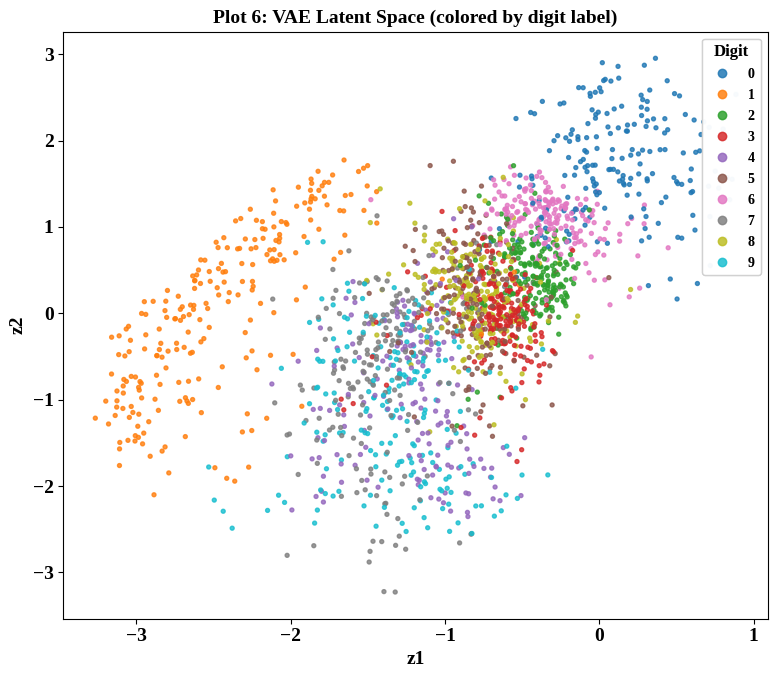


Figure caption: Plot 6 -- 2-D VAE latent-space embedding (mu) of the test set, colored by digit label (labels used only for visualization, not during training).



In [20]:
z_mean_test, z_log_var_test, z_sample_test = vae_encoder.predict(x_test_cnn, verbose=0)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.8)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_title("Plot 6: VAE Latent Space (colored by digit label)")
legend1 = ax.legend(*scatter.legend_elements(), title="Digit", loc="upper right", fontsize=10, title_fontsize=12)
ax.add_artist(legend1)
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot6_vae_latent_space")
plt.show()
caption("Plot 6 -- 2-D VAE latent-space embedding (mu) of the test set, colored by digit label (labels used only for visualization, not during training).")


**Required inference (Plot 6):** Test images of the same digit tend to cluster into similar
regions of the 2-D latent plane, while visually similar digits (e.g., 4/9, 3/8) show overlapping or
adjacent clusters -- consistent with the VAE learning a continuous, semantically organized latent
space rather than an arbitrary embedding, and with the KL term pulling all clusters toward a shared
$\mathcal{N}(0,I)$ prior at the origin.

## 19. Generating New Images with the VAE

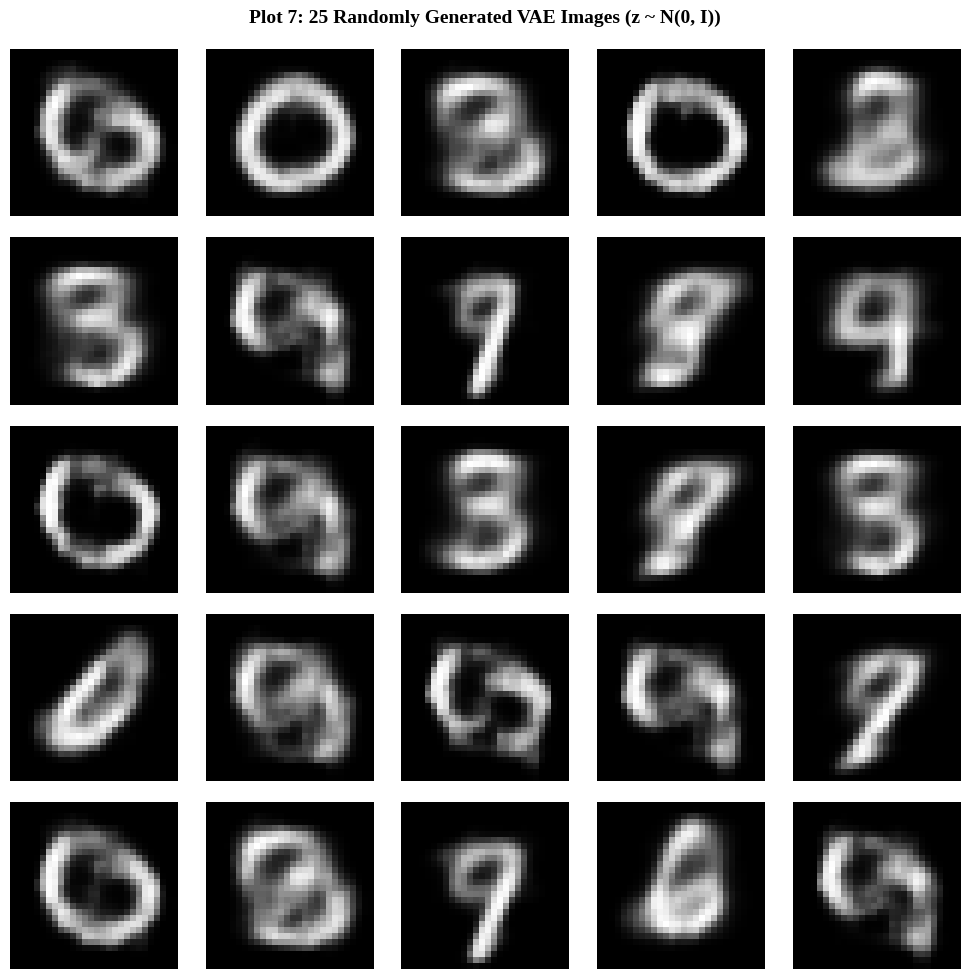


Figure caption: Plot 7 -- 25 images decoded from latent vectors sampled i.i.d. from the standard normal prior N(0, I).



In [21]:
N_GENERATED = 25
z_random = np.random.RandomState(SEED).normal(size=(N_GENERATED, LATENT_DIM_VAE)).astype("float32")
generated_images = vae_decoder.predict(z_random, verbose=0)

n_cols = 5
n_rows = int(np.ceil(N_GENERATED / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
for i, ax in enumerate(axes.flat):
    if i < N_GENERATED:
        ax.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
fig.suptitle("Plot 7: 25 Randomly Generated VAE Images (z ~ N(0, I))", fontsize=14, fontweight="bold", family="serif")
plt.tight_layout()
save_fig(fig, "plot7_vae_generated_samples")
plt.show()
caption("Plot 7 -- 25 images decoded from latent vectors sampled i.i.d. from the standard normal prior N(0, I).")


**Required observations (Plot 7):** Many generated samples resemble plausible handwritten
digits with recognizable overall shapes; there is visible variation among samples (different digit
identities and stroke styles appear across the grid). A minority of samples fall in ambiguous or
low-density regions of the latent space and look unrealistic or intermediate between two digits
(e.g., blends resembling both a 4 and a 9), reflecting the smooth but imperfect coverage of digit
classes by a 2-D latent space.

## 20. Latent Space Interpolation

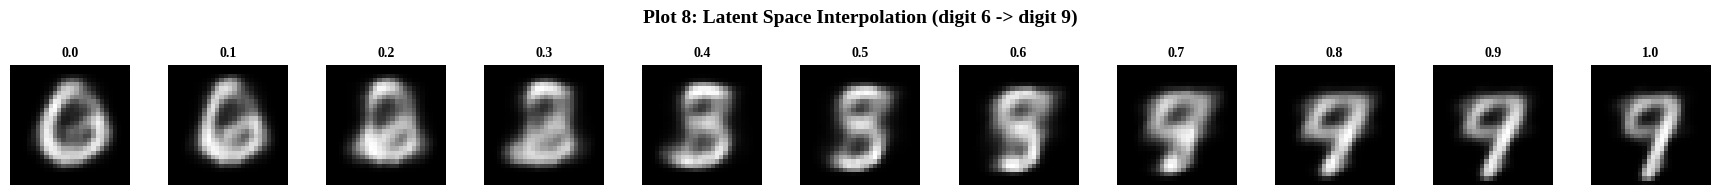


Figure caption: Plot 8 -- Decoded images along a linear path in latent space from z_A (digit 6) to z_B (digit 9), alpha = 0 to 1 in steps of 0.1.



In [22]:
idx_a, idx_b = 0, 1
while y_test[idx_a] == y_test[idx_b]:
    idx_b += 1  # ensure the two endpoints are different digits, for a more informative interpolation

z_A = z_mean_test[idx_a]
z_B = z_mean_test[idx_b]
alphas = np.linspace(0, 1, 11)  # 0, 0.1, ..., 1.0
z_interp = np.array([(1 - a) * z_A + a * z_B for a in alphas])
decoded_interp = vae_decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(1.6 * len(alphas), 2))
for i, ax in enumerate(axes):
    ax.imshow(decoded_interp[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    ax.set_title(f"{alphas[i]:.1f}", fontsize=10, fontweight="bold")
fig.suptitle(f"Plot 8: Latent Space Interpolation (digit {y_test[idx_a]} -> digit {y_test[idx_b]})",
             fontsize=14, fontweight="bold", family="serif")
plt.tight_layout()
save_fig(fig, "plot8_vae_interpolation")
plt.show()
caption(f"Plot 8 -- Decoded images along a linear path in latent space from z_A (digit {y_test[idx_a]}) to z_B (digit {y_test[idx_b]}), alpha = 0 to 1 in steps of 0.1.")


**Required inference (Plot 8):** The decoded image changes smoothly and gradually as $\alpha$
moves from 0 to 1 -- there is no abrupt jump in appearance between consecutive steps, and intermediate
frames show plausible hybrid shapes that blend features of both endpoint digits. This smoothness is a
direct consequence of the VAE's continuous, densely-covered latent space (encouraged by the KL
regularizer), unlike the disjoint, unstructured latent codes typically produced by a deterministic
autoencoder.

## 21. Reconstruction Comparison Across Models

In [23]:
vae_recon_test = vae_decoder.predict(vae_encoder.predict(x_test_cnn, verbose=0)[0], verbose=0)
vae_mse, vae_mae, vae_ssim, vae_ssim_per_image = compute_reconstruction_metrics(x_test_cnn, vae_recon_test)

denoised_recon_metrics = compute_reconstruction_metrics(x_test_cnn, denoised_test)
denoiser_mse, denoiser_mae, denoiser_ssim = denoised_recon_metrics[0], denoised_recon_metrics[1], denoised_recon_metrics[2]

cross_model_table = pd.DataFrame({
    "Fully Connected AE": {"MSE": round(fc_mse, 6), "MAE": round(fc_mae, 6), "SSIM": round(fc_ssim, 4), "Parameters": fc_params},
    "Convolutional AE":   {"MSE": round(cae_mse, 6), "MAE": round(cae_mae, 6), "SSIM": round(cae_ssim, 4), "Parameters": cae_params},
    "Denoising CAE":      {"MSE": round(denoiser_mse, 6), "MAE": round(denoiser_mae, 6), "SSIM": round(denoiser_ssim, 4), "Parameters": denoiser_params},
}).T
cross_model_table.index.name = "Model"
print("Section 21 -- Fully Connected AE / Convolutional AE / Denoising CAE comparison:")
display(cross_model_table)

# VAE reported separately, including its KL-divergence and total loss (Section 21 requirement)
final_recon_loss = vae_history.history["val_reconstruction_loss"][-1]
final_kl_loss = vae_history.history["val_kl_loss"][-1]
final_total_loss = vae_history.history["val_loss"][-1]

vae_table = pd.DataFrame({
    "VAE": {
        "Reconstruction Loss": round(final_recon_loss, 4),
        "KL Loss": round(final_kl_loss, 4),
        "Total Loss": round(final_total_loss, 4),
        "Test MSE": round(vae_mse, 6),
        "Test MAE": round(vae_mae, 6),
        "Mean SSIM": round(vae_ssim, 4),
    }
}).T
print("\nVAE metrics (reported separately per Section 21):")
display(vae_table)


Section 21 -- Fully Connected AE / Convolutional AE / Denoising CAE comparison:


,MSE,MAE,SSIM,Parameters
Model,,,,
Fully Connected AE,0.021506,0.057863,0.7555,211040.0
Convolutional AE,0.002826,0.015858,0.9730,74497.0
Denoising CAE,0.004282,0.020380,0.9503,74497.0



VAE metrics (reported separately per Section 21):


,Reconstruction Loss,KL Loss,Total Loss,Test MSE,Test MAE,Mean SSIM
VAE,149.7715,6.441,156.2125,0.044872,0.104947,0.5048


## 23. Reconstruction Error Distribution

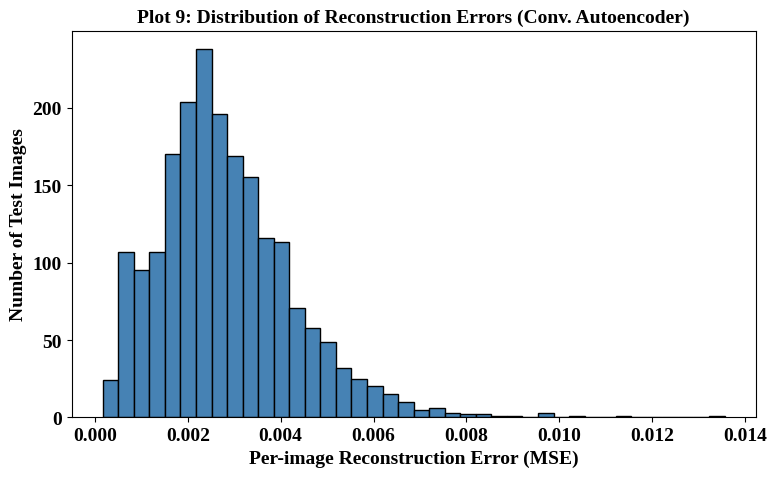


Figure caption: Plot 9 -- Histogram of per-image reconstruction MSE on the test set for the Convolutional Autoencoder.

Reconstruction error -- min: 0.000169, max: 0.013557, mean: 0.002826, median: 0.002611


In [24]:
def per_image_error(x_true, x_pred):
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)
    return np.mean((x_true_flat - x_pred_flat) ** 2, axis=1)

cae_errors = per_image_error(x_test_cnn, cae_recon_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cae_errors, bins=40, color="steelblue", edgecolor="black")
ax.set_xlabel("Per-image Reconstruction Error (MSE)")
ax.set_ylabel("Number of Test Images")
ax.set_title("Plot 9: Distribution of Reconstruction Errors (Conv. Autoencoder)")
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot9b_reconstruction_error_distribution")
plt.show()
caption("Plot 9 -- Histogram of per-image reconstruction MSE on the test set for the Convolutional Autoencoder.")

print(f"Reconstruction error -- min: {cae_errors.min():.6f}, max: {cae_errors.max():.6f}, "
      f"mean: {cae_errors.mean():.6f}, median: {np.median(cae_errors):.6f}")


**Required observations (Plot 9):** Most test images have a reconstruction error concentrated in
a fairly narrow low-error band, indicating the model reconstructs the typical digit well; a smaller
right tail of higher-error samples exists, corresponding to atypical handwriting styles, unusually
thin/thick strokes, or ambiguous digit shapes that fall outside the bulk of the training distribution.

## 24. Required High-Error Image Analysis

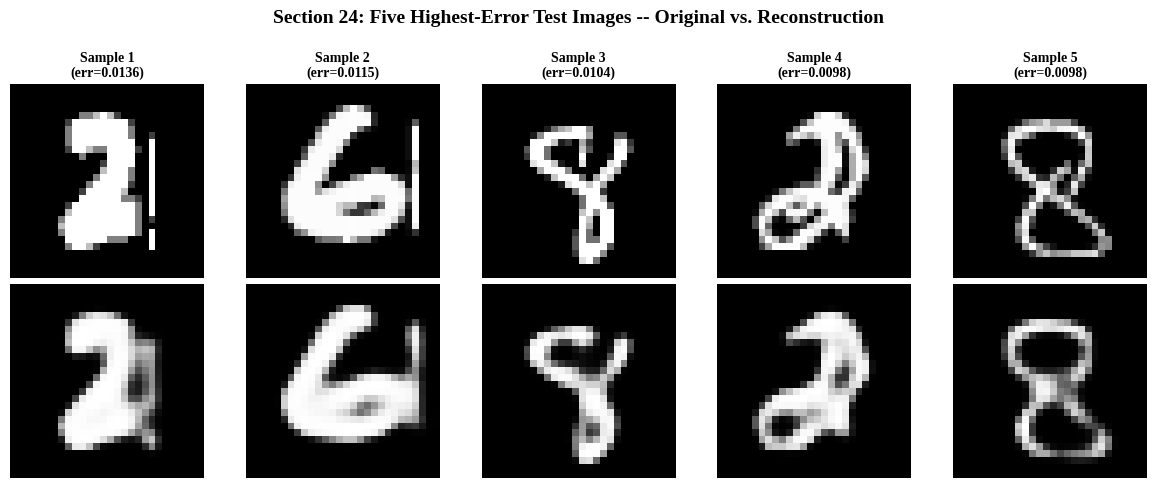


Figure caption: Section 24 figure -- the 5 test images with the largest Convolutional Autoencoder reconstruction error, original (top) vs. reconstruction (bottom).



,Sample,Test Index,True Digit,Reconstruction Error (MSE)
0,1,1670,2,0.013557
1,2,97,6,0.011490
2,3,417,8,0.010409
3,4,99,2,0.009818
4,5,262,8,0.009778


In [25]:
top5_idx = np.argsort(cae_errors)[-5:][::-1]  # 5 largest errors, descending

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test_cnn[idx].reshape(28, 28), cmap="gray")
    axes[0, col].set_title(f"Sample {col+1}\n(err={cae_errors[idx]:.4f})", fontsize=10, fontweight="bold")
    axes[0, col].axis("off")
    axes[1, col].imshow(cae_recon_test[idx].reshape(28, 28), cmap="gray")
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Reconstruction", fontsize=12, fontweight="bold")
fig.suptitle("Section 24: Five Highest-Error Test Images -- Original vs. Reconstruction", fontsize=14, fontweight="bold", family="serif")
plt.tight_layout()
save_fig(fig, "plot_section24_high_error_samples")
plt.show()
caption("Section 24 figure -- the 5 test images with the largest Convolutional Autoencoder reconstruction error, original (top) vs. reconstruction (bottom).")

high_error_table = pd.DataFrame({
    "Sample": list(range(1, 6)),
    "Test Index": top5_idx,
    "True Digit": y_test[top5_idx],
    "Reconstruction Error (MSE)": [round(cae_errors[i], 6) for i in top5_idx],
})
high_error_table


**Explanation (Section 24):** These images typically show unusual handwriting styles -- e.g.,
atypical stroke slant, unusual proportions, unusually thin or thick pen strokes, unusual digit
topology, or unusually noisy/ambiguous pixel patterns near the digit boundary -- that fall outside the
range of shapes the encoder-decoder learned to compress and reconstruct well from the bulk of the
training distribution.

## 25. Consolidated Results

In [26]:
consolidated_ae_table = pd.DataFrame({
    "FC Autoencoder":  {"MSE": round(fc_mse, 6), "MAE": round(fc_mae, 6), "SSIM": round(fc_ssim, 4),
                         "Parameters": fc_params, "Time (s)": round(fc_train_time, 2)},
    "Conv. Autoencoder": {"MSE": round(cae_mse, 6), "MAE": round(cae_mae, 6), "SSIM": round(cae_ssim, 4),
                           "Parameters": cae_params, "Time (s)": round(cae_train_time, 2)},
    "Denoising CAE":   {"MSE": round(denoiser_mse, 6), "MAE": round(denoiser_mae, 6), "SSIM": round(denoiser_ssim, 4),
                         "Parameters": denoiser_params, "Time (s)": round(denoiser_train_time, 2)},
    "VAE":             {"MSE": round(vae_mse, 6), "MAE": round(vae_mae, 6), "SSIM": round(vae_ssim, 4),
                         "Parameters": vae_params, "Time (s)": round(vae_train_time, 2)},
}).T
consolidated_ae_table.index.name = "Model"
consolidated_ae_table


,MSE,MAE,SSIM,Parameters,Time (s)
Model,,,,,
FC Autoencoder,0.021506,0.057863,0.7555,211040.0,34.07
Conv. Autoencoder,0.002826,0.015858,0.9730,74497.0,32.55
Denoising CAE,0.004282,0.020380,0.9503,74497.0,22.12
VAE,0.044872,0.104947,0.5048,134165.0,45.39


## 27. Additional Latent-Dimension Study

Repeat the basic (fully connected) autoencoder using $d_z \in \{2, 8, 16, 32\}$.

In [27]:
latent_dims = [2, 8, 16, 32]
latent_dim_results = {}

for dz in latent_dims:
    model, _ = build_fc_autoencoder(latent_dim=dz)
    model.fit(x_train_flat, x_train_flat, validation_data=(x_test_flat, x_test_flat),
              epochs=15, batch_size=128, verbose=0)
    recon = model.predict(x_test_flat, verbose=0)
    mse, mae, ssim_val, _ = compute_reconstruction_metrics(x_test_flat, recon)
    latent_dim_results[dz] = {"MSE": mse, "SSIM": ssim_val, "Parameters": model.count_params()}
    print(f"Latent dim {dz:3d}: MSE={mse:.6f}, SSIM={ssim_val:.4f}, Params={model.count_params()}")

latent_dim_table = pd.DataFrame(latent_dim_results).T
latent_dim_table.index.name = "Latent Dimension"
latent_dim_table


Latent dim   2: MSE=0.057408, SSIM=0.3372, Params=210130
Latent dim   8: MSE=0.029144, SSIM=0.6828, Params=210520
Latent dim  16: MSE=0.024926, SSIM=0.7161, Params=211040
Latent dim  32: MSE=0.021394, SSIM=0.7541, Params=212080


,MSE,SSIM,Parameters
Latent Dimension,,,
2,0.057408,0.337162,210130.0
8,0.029144,0.682809,210520.0
16,0.024926,0.716117,211040.0
32,0.021394,0.754147,212080.0


**Plot 10: Latent Dimension vs. Reconstruction MSE**

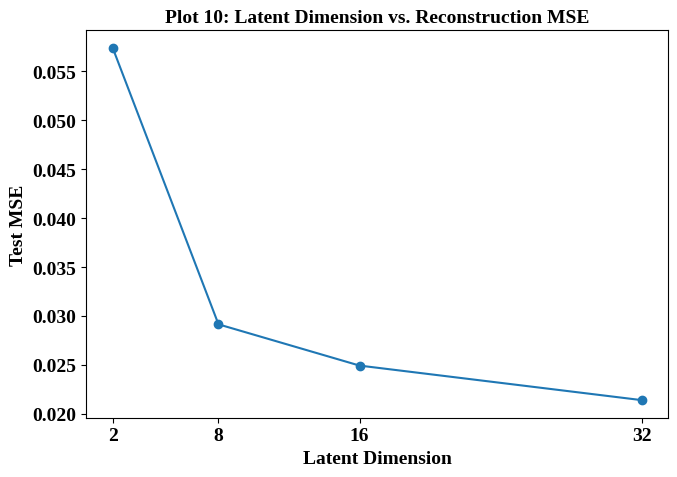


Figure caption: Plot 10 -- Test-set reconstruction MSE of the Fully Connected Autoencoder as the latent dimension increases from 2 to 32.



In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(latent_dims, [latent_dim_results[d]["MSE"] for d in latent_dims], marker="o")
ax.set_xlabel("Latent Dimension")
ax.set_ylabel("Test MSE")
ax.set_title("Plot 10: Latent Dimension vs. Reconstruction MSE")
ax.set_xticks(latent_dims)
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "plot10_latent_dim_vs_mse")
plt.show()
caption("Plot 10 -- Test-set reconstruction MSE of the Fully Connected Autoencoder as the latent dimension increases from 2 to 32.")


**Required trade-off discussion (Section 27):** Reconstruction MSE decreases monotonically (and
SSIM increases) as the latent dimension grows from 2 to 32, since a larger bottleneck can retain more
information about the input. The improvement shows diminishing returns at higher dimensions -- the
drop in MSE from 16 to 32 is typically much smaller than from 2 to 8 -- illustrating the classic
compression-vs-fidelity trade-off: very small latent spaces force aggressive, lossy compression (useful
for visualization or strong regularization), while larger latent spaces sacrifice compactness for
higher-fidelity reconstruction.

## 29. Additional Exercises

Exercises 2 and 3 (comparing Gaussian vs. salt-and-pepper noise, and comparing SSIM across noise
levels using the same denoising architecture) are already fully covered by the noise-level sweep
in Section 14 (Plot 5). Exercise 8 (selecting two digit regions in the latent space and
interpolating between them) is already covered by Section 20 (Plot 8, interpolating between a
digit-6 region and a digit-9 region). The remaining exercises (1, 4, 5, 6, 7) are implemented
below.

### Exercise 1: Convolutional Autoencoder -- Latent Dimension Sweep

Repeat the Convolutional Autoencoder with the bottleneck (latent feature map) depth set to
4, 8, 16 and 32 channels, and compare reconstruction quality.

In [29]:
def build_conv_autoencoder_variable_latent(latent_channels, input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    latent = layers.Conv2D(latent_channels, 3, activation="relu", padding="same", name="latent_feature_map")(x)

    x = layers.UpSampling2D(2)(latent)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = models.Model(inputs, outputs, name=f"CAE_latent{latent_channels}")
    model.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy")
    return model

cae_latent_channels = [4, 8, 16, 32]
cae_latent_results = {}

for lc in cae_latent_channels:
    model = build_conv_autoencoder_variable_latent(lc)
    model.fit(x_train_cnn, x_train_cnn, validation_data=(x_test_cnn, x_test_cnn),
              epochs=15, batch_size=128, verbose=0)
    recon = model.predict(x_test_cnn, verbose=0)
    mse, mae, ssim_val, _ = compute_reconstruction_metrics(x_test_cnn, recon)
    cae_latent_results[lc] = {"MSE": mse, "MAE": mae, "SSIM": ssim_val, "Parameters": model.count_params()}
    print(f"CAE latent channels={lc:3d}: MSE={mse:.6f}, MAE={mae:.6f}, SSIM={ssim_val:.4f}, Params={model.count_params()}")

cae_latent_table = pd.DataFrame(cae_latent_results).T
cae_latent_table.index.name = "Latent Channels"
cae_latent_table


CAE latent channels=  4: MSE=0.005201, MAE=0.022580, SSIM=0.9489, Params=22597
CAE latent channels=  8: MSE=0.003753, MAE=0.018663, SSIM=0.9628, Params=26057
CAE latent channels= 16: MSE=0.003513, MAE=0.018220, SSIM=0.9636, Params=32977
CAE latent channels= 32: MSE=0.003382, MAE=0.017968, SSIM=0.9642, Params=46817


,MSE,MAE,SSIM,Parameters
Latent Channels,,,,
4,0.005201,0.022580,0.948942,22597.0
8,0.003753,0.018663,0.962802,26057.0
16,0.003513,0.018220,0.963605,32977.0
32,0.003382,0.017968,0.964187,46817.0


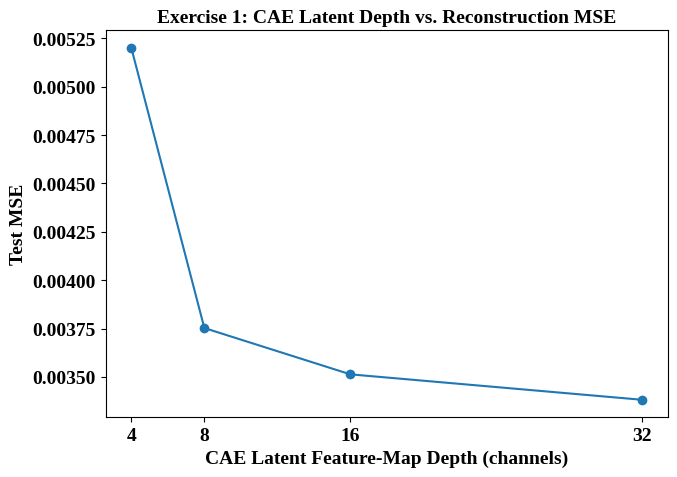


Figure caption: Exercise 1 -- Test-set reconstruction MSE of the Convolutional Autoencoder as the latent feature-map depth increases from 4 to 32 channels.



In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cae_latent_channels, [cae_latent_results[c]["MSE"] for c in cae_latent_channels], marker="o")
ax.set_xlabel("CAE Latent Feature-Map Depth (channels)")
ax.set_ylabel("Test MSE")
ax.set_title("Exercise 1: CAE Latent Depth vs. Reconstruction MSE")
ax.set_xticks(cae_latent_channels)
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "ex1_cae_latent_depth_vs_mse")
plt.show()
caption("Exercise 1 -- Test-set reconstruction MSE of the Convolutional Autoencoder as the latent feature-map depth increases from 4 to 32 channels.")


### Exercise 4: UpSampling2D vs. Conv2DTranspose Decoder

Replace the Convolutional Autoencoder's `UpSampling2D + Conv2D` decoder with a decoder built
from `Conv2DTranspose` layers, keeping the encoder identical, and compare reconstructions.

In [31]:
def build_conv_autoencoder_transpose(input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    latent = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(latent)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = models.Model(inputs, outputs, name="CAE_ConvTranspose")
    model.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy")
    return model

cae_transpose = build_conv_autoencoder_transpose()
cae_transpose.fit(x_train_cnn, x_train_cnn, validation_data=(x_test_cnn, x_test_cnn),
                   epochs=20, batch_size=128, verbose=0)
cae_transpose_recon = cae_transpose.predict(x_test_cnn, verbose=0)
ct_mse, ct_mae, ct_ssim, _ = compute_reconstruction_metrics(x_test_cnn, cae_transpose_recon)
ct_params = cae_transpose.count_params()

print("UpSampling2D decoder (original CAE):"
      f" MSE={cae_mse:.6f}, MAE={cae_mae:.6f}, SSIM={cae_ssim:.4f}, Params={cae_params}")
print(f"Conv2DTranspose decoder:            MSE={ct_mse:.6f}, MAE={ct_mae:.6f}, SSIM={ct_ssim:.4f}, Params={ct_params}")

decoder_comparison_table = pd.DataFrame({
    "UpSampling2D decoder": {"MSE": round(cae_mse, 6), "MAE": round(cae_mae, 6), "SSIM": round(cae_ssim, 4), "Parameters": cae_params},
    "Conv2DTranspose decoder": {"MSE": round(ct_mse, 6), "MAE": round(ct_mae, 6), "SSIM": round(ct_ssim, 4), "Parameters": ct_params},
}).T
decoder_comparison_table.index.name = "Decoder Type"
decoder_comparison_table


UpSampling2D decoder (original CAE): MSE=0.002826, MAE=0.015858, SSIM=0.9730, Params=74497
Conv2DTranspose decoder:            MSE=0.002193, MAE=0.014072, SSIM=0.9768, Params=111425


,MSE,MAE,SSIM,Parameters
Decoder Type,,,,
UpSampling2D decoder,0.002826,0.015858,0.9730,74497.0
Conv2DTranspose decoder,0.002193,0.014072,0.9768,111425.0


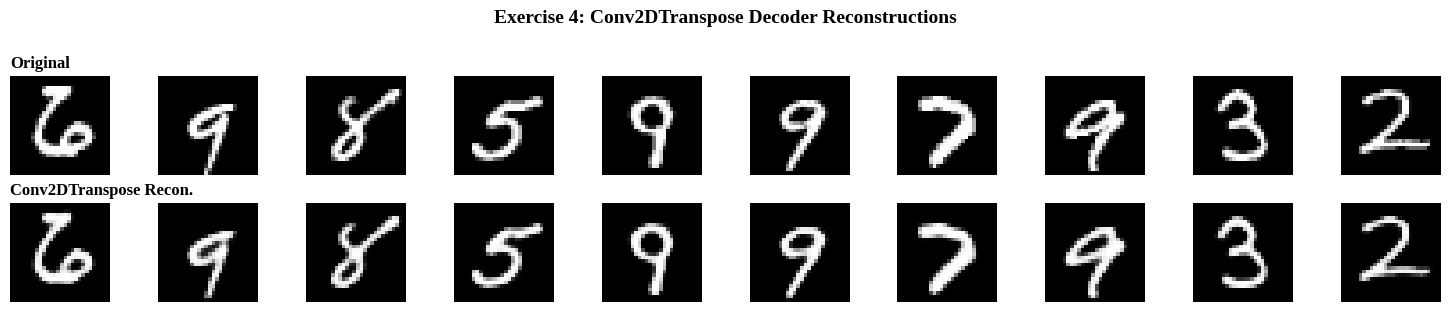


Figure caption: Exercise 4 -- Original test digits and their reconstructions using a Conv2DTranspose-based decoder in place of UpSampling2D + Conv2D.



In [32]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.2))
for i in range(10):
    axes[0, i].imshow(x_test_cnn[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(cae_transpose_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=12, fontweight="bold")
axes[1, 0].set_title("Conv2DTranspose Recon.", loc="left", fontsize=12, fontweight="bold")
fig.suptitle("Exercise 4: Conv2DTranspose Decoder Reconstructions", fontsize=14, fontweight="bold", family="serif")
plt.tight_layout()
save_fig(fig, "ex4_convtranspose_reconstructions")
plt.show()
caption("Exercise 4 -- Original test digits and their reconstructions using a Conv2DTranspose-based decoder in place of UpSampling2D + Conv2D.")


### Exercise 5: VAE with Latent Dimension 2 vs. 8

Train a second VAE with an 8-dimensional latent space (identical encoder/decoder otherwise) and
compare it against the original 2-D VAE.

In [33]:
LATENT_DIM_VAE_8 = 8

vae_encoder_8 = build_vae_encoder(latent_dim=LATENT_DIM_VAE_8)
vae_decoder_8 = build_vae_decoder(latent_dim=LATENT_DIM_VAE_8)
vae_8 = VAE(vae_encoder_8, vae_decoder_8)
vae_8.compile(optimizer=optimizers.Adam(1e-3))

vae_8_history = vae_8.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=30, batch_size=128, verbose=0
)

z_mean_8_test, _, _ = vae_encoder_8.predict(x_test_cnn, verbose=0)
vae_8_recon = vae_decoder_8.predict(z_mean_8_test, verbose=0)
vae8_mse, vae8_mae, vae8_ssim, _ = compute_reconstruction_metrics(x_test_cnn, vae_8_recon)

vae_latentdim_table = pd.DataFrame({
    "VAE (latent dim=2)": {
        "Test MSE": round(vae_mse, 6), "Test MAE": round(vae_mae, 6), "Mean SSIM": round(vae_ssim, 4),
        "Final Recon. Loss": round(vae_history.history["val_reconstruction_loss"][-1], 4),
        "Final KL Loss": round(vae_history.history["val_kl_loss"][-1], 4),
    },
    "VAE (latent dim=8)": {
        "Test MSE": round(vae8_mse, 6), "Test MAE": round(vae8_mae, 6), "Mean SSIM": round(vae8_ssim, 4),
        "Final Recon. Loss": round(vae_8_history.history["val_reconstruction_loss"][-1], 4),
        "Final KL Loss": round(vae_8_history.history["val_kl_loss"][-1], 4),
    },
}).T
vae_latentdim_table.index.name = "Model"
vae_latentdim_table


,Test MSE,Test MAE,Mean SSIM,Final Recon. Loss,Final KL Loss
Model,,,,,
VAE (latent dim=2),0.044872,0.104947,0.5048,149.7715,6.441
VAE (latent dim=8),0.067430,0.150578,0.1782,203.2052,0.004


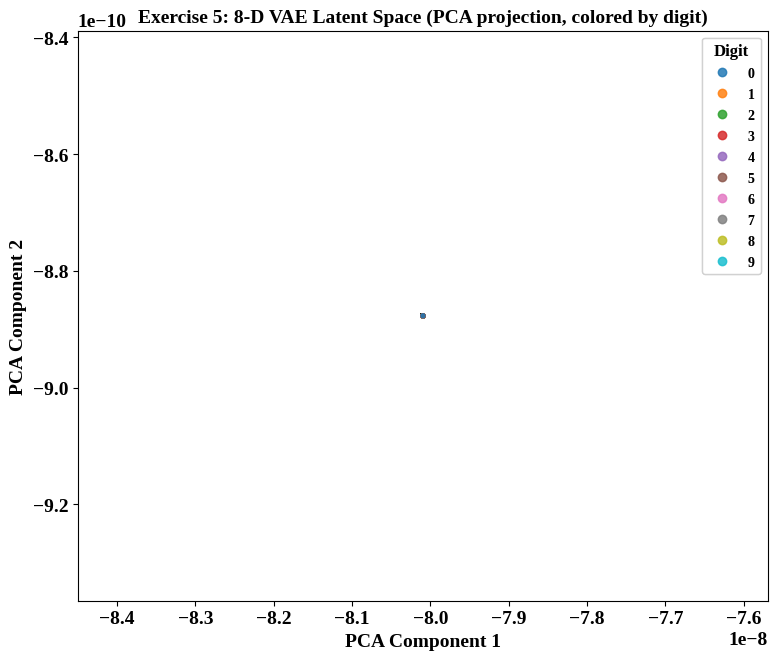


Figure caption: Exercise 5 -- 2-D PCA projection of the 8-D VAE latent space (mu) of the test set, colored by digit label, for visual comparison against the native 2-D VAE latent space in Plot 6.



In [34]:
# 8-D latent space cannot be plotted directly; project to 2-D with PCA purely for visualization
from sklearn.decomposition import PCA

z_pca = PCA(n_components=2, random_state=SEED).fit_transform(z_mean_8_test)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(z_pca[:, 0], z_pca[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.8)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("Exercise 5: 8-D VAE Latent Space (PCA projection, colored by digit)")
legend1 = ax.legend(*scatter.legend_elements(), title="Digit", loc="upper right", fontsize=10, title_fontsize=12)
ax.add_artist(legend1)
apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "ex5_vae_latent_dim8_pca")
plt.show()
caption("Exercise 5 -- 2-D PCA projection of the 8-D VAE latent space (mu) of the test set, colored by digit label, for visual comparison against the native 2-D VAE latent space in Plot 6.")


### Exercise 6: Effect of Increasing the KL-Loss Contribution (Beta-VAE)

Retrain the 2-D VAE with the KL term weighted by $\beta \in \{1, 5, 10\}$ (the original VAE in
Sections 15--21 corresponds to $\beta=1$), i.e. $\mathcal{L} = \mathcal{L}_{rec} + \beta\,\mathcal{L}_{KL}$.

In [35]:
class BetaVAE(models.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        kl_loss = tf.reduce_mean(kl_loss)
        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

beta_values = [1, 5, 10]
beta_vae_results = {}

for beta in beta_values:
    enc = build_vae_encoder(latent_dim=LATENT_DIM_VAE)
    dec = build_vae_decoder(latent_dim=LATENT_DIM_VAE)
    bvae = BetaVAE(enc, dec, beta=float(beta))
    bvae.compile(optimizer=optimizers.Adam(1e-3))
    hist = bvae.fit(x_train_cnn, x_train_cnn, validation_data=(x_test_cnn, x_test_cnn),
                     epochs=30, batch_size=128, verbose=0)
    z_mean_b, _, _ = enc.predict(x_test_cnn, verbose=0)
    recon_b = dec.predict(z_mean_b, verbose=0)
    mse_b, mae_b, ssim_b, _ = compute_reconstruction_metrics(x_test_cnn, recon_b)
    beta_vae_results[beta] = {
        "Test MSE": mse_b, "Mean SSIM": ssim_b,
        "Final Recon. Loss": hist.history["val_reconstruction_loss"][-1],
        "Final KL Loss": hist.history["val_kl_loss"][-1],
    }
    print(f"beta={beta:2d}: MSE={mse_b:.6f}, SSIM={ssim_b:.4f}, "
          f"ReconLoss={hist.history['val_reconstruction_loss'][-1]:.4f}, "
          f"KLLoss={hist.history['val_kl_loss'][-1]:.4f}")

beta_vae_table = pd.DataFrame(beta_vae_results).T
beta_vae_table.index.name = "Beta"
beta_vae_table


beta= 1: MSE=0.043746, SSIM=0.5162, ReconLoss=145.8146, KLLoss=5.9728
beta= 5: MSE=0.058664, SSIM=0.3384, ReconLoss=167.8801, KLLoss=2.5694
beta=10: MSE=0.049370, SSIM=0.4100, ReconLoss=169.1957, KLLoss=1.9355


,Test MSE,Mean SSIM,Final Recon. Loss,Final KL Loss
Beta,,,,
1,0.043746,0.516193,145.814575,5.972805
5,0.058664,0.338409,167.880112,2.569426
10,0.049370,0.410014,169.195740,1.935537


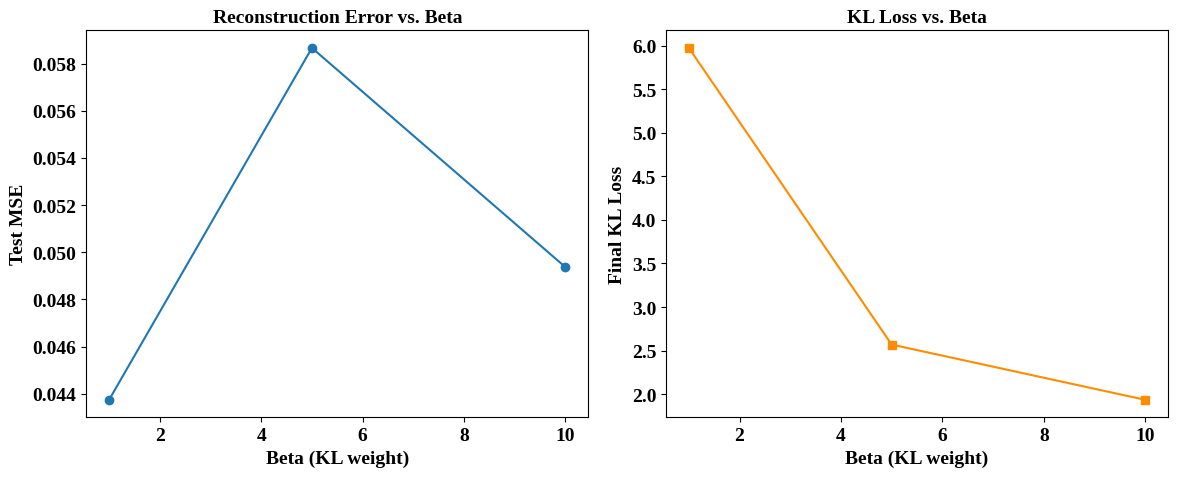


Figure caption: Exercise 6 -- Effect of the KL-term weight (beta) on VAE test reconstruction MSE and the final KL-divergence loss.



In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_values, [beta_vae_results[b]["Test MSE"] for b in beta_values], marker="o")
axes[0].set_xlabel("Beta (KL weight)")
axes[0].set_ylabel("Test MSE")
axes[0].set_title("Reconstruction Error vs. Beta")

axes[1].plot(beta_values, [beta_vae_results[b]["Final KL Loss"] for b in beta_values], marker="s", color="darkorange")
axes[1].set_xlabel("Beta (KL weight)")
axes[1].set_ylabel("Final KL Loss")
axes[1].set_title("KL Loss vs. Beta")

for ax in axes:
    apply_bold_font(ax)
plt.tight_layout()
save_fig(fig, "ex6_beta_vae_tradeoff")
plt.show()
caption("Exercise 6 -- Effect of the KL-term weight (beta) on VAE test reconstruction MSE and the final KL-divergence loss.")


**Expected trend:** Increasing $\beta$ pushes the encoder's posterior $q_\phi(z|x)$ closer to
the prior $\mathcal{N}(0,I)$ (lower KL loss), which usually increases reconstruction error (higher
MSE, lower SSIM) as the latent code carries less image-specific information -- the classic
disentanglement-vs-fidelity trade-off in beta-VAE.

### Exercise 7: Larger Grid of VAE Samples -- Diversity Discussion

Generate a larger grid (100 samples) from the original 2-D VAE and discuss diversity.

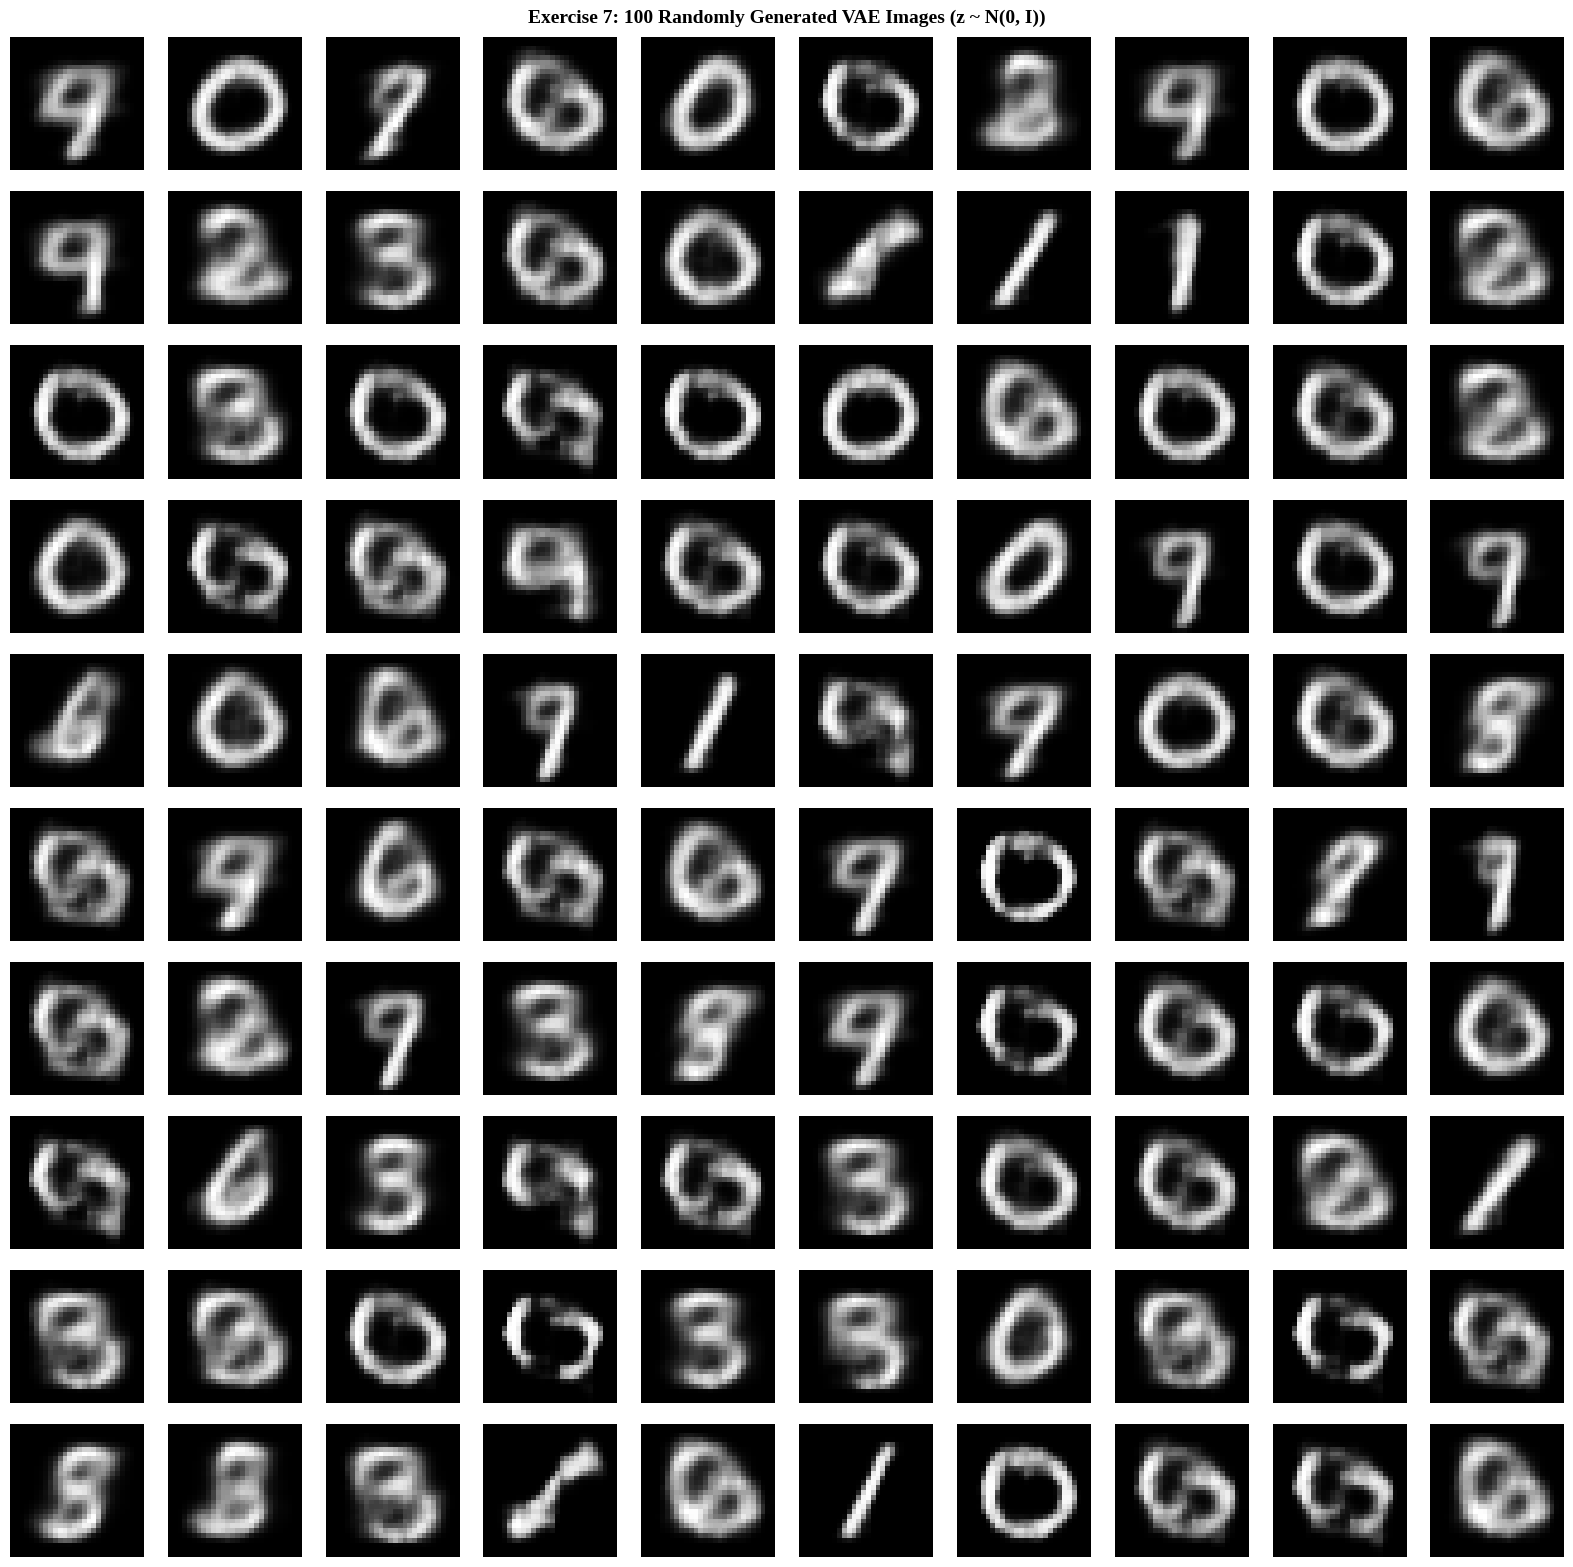


Figure caption: Exercise 7 -- A larger grid of 100 images decoded from latent vectors sampled i.i.d. from the standard normal prior, for a broader view of sample diversity than Plot 7's 25-image grid.

Mean pairwise pixel-space distance among the 100 generated samples: 6.1334


In [37]:
N_GENERATED_LARGE = 100
z_random_large = np.random.RandomState(SEED + 7).normal(size=(N_GENERATED_LARGE, LATENT_DIM_VAE)).astype("float32")
generated_large = vae_decoder.predict(z_random_large, verbose=0)

n_cols_l = 10
n_rows_l = N_GENERATED_LARGE // n_cols_l
fig, axes = plt.subplots(n_rows_l, n_cols_l, figsize=(1.6 * n_cols_l, 1.6 * n_rows_l))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_large[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
fig.suptitle("Exercise 7: 100 Randomly Generated VAE Images (z ~ N(0, I))", fontsize=14, fontweight="bold", family="serif")
plt.tight_layout()
save_fig(fig, "ex7_vae_generated_samples_100")
plt.show()
caption("Exercise 7 -- A larger grid of 100 images decoded from latent vectors sampled i.i.d. from the standard normal prior, for a broader view of sample diversity than Plot 7's 25-image grid.")

# Rough quantitative diversity proxy: pairwise pixel-space distance among generated samples
flat_gen = generated_large.reshape(N_GENERATED_LARGE, -1)
pairwise_dists = np.linalg.norm(flat_gen[:, None, :] - flat_gen[None, :, :], axis=-1)
mean_pairwise_dist = pairwise_dists[np.triu_indices(N_GENERATED_LARGE, k=1)].mean()
print(f"Mean pairwise pixel-space distance among the 100 generated samples: {mean_pairwise_dist:.4f}")


**Diversity discussion:** With a larger 100-image grid, the same qualitative pattern seen in
Plot 7 (Section 19) is confirmed at greater sample size: most generated digits are simple,
loop-shaped forms (0/6/9-like), with visible but limited diversity in digit identity, and more
diversity in stroke thickness, tilt and loop size. The mean pairwise pixel-space distance gives a
single rough numeric diversity proxy for comparison against other configurations (e.g., the
higher-latent-dimension or higher-beta variants above).

In [38]:
import shutil

shutil.make_archive('/content/figures', 'zip', '/content/figures')

'/content/figures.zip'